In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [15]:
# path = r"C://Users//shadj//Desktop//Research//Code//app_data.xlsx"
df = pd.read_excel("app_data.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

In [16]:
df["Diagnosis"].value_counts()

Diagnosis
appendicitis       463
no appendicitis    317
Name: count, dtype: int64

In [17]:
df.shape

(782, 58)

In [18]:
# from sklearn.model_selection import train_test_split
# df.loc[:,"Diagnosis"].dropna(inplace=True)
# df["Diagnosis"].value_counts(dropna=False)
# #df["Diagnosis"] = df[df["Diagnosis"]=="appendicitis"].astype(int)

In [19]:
#checking the value of Diagnosis Column
df['Diagnosis'].value_counts(dropna = False)


Diagnosis
appendicitis       463
no appendicitis    317
NaN                  2
Name: count, dtype: int64

In [20]:
# removing the rows whose diagnosis column is nan
df = df[df['Diagnosis'].notna()]
df['Diagnosis'].value_counts(dropna = False)

Diagnosis
appendicitis       463
no appendicitis    317
Name: count, dtype: int64

In [21]:
#converting the diagnosis value to int type
df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)

In [25]:
# correlation of different columns with each other
# df.corr()

In [27]:
#  correlation of our output column with other columns
# df.corr()['Diagnosis']

In [28]:
# list of columns with contains data of the ultrasound and have very few non na values
US_columns = ['US_Performed','US_Number','Appendix_Wall_Layers','Target_Sign','Perfusion',"Surrounding_Tissue_Reaction",
              "Pathological_Lymph_Nodes","Lymph_Nodes_Location","Bowel_Wall_Thickening","Ileus","Coprostasis","Meteorism","Enteritis","Appendicolith",
               "Perforation","Appendicular_Abscess","Abscess_Location","Conglomerate_of_Bowel_Loops","Gynecological_Findings"]

In [29]:
df["Appendix_on_US"].value_counts()

Appendix_on_US
yes    504
no     273
Name: count, dtype: int64

In [31]:
df["Appendix_on_US"] = (df["Appendix_on_US"]=='yes').astype(int)

In [32]:
# since this is early diagnosing therfore assuming that the US is not performed
# Hence removing all the columns that contains information of an ultrasound
df.drop(US_columns,axis=1,inplace=True)

In [33]:
df

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,1,...,++,+,no,0.0,no,normal,no,yes,no,no
1,14.100000,31.900000,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,yes,normal,no,yes,no,no
2,14.140000,23.300000,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,no,constipation,no,yes,no,no
3,16.370000,20.600000,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,0.0,yes,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,1,...,no,no,no,0.0,no,constipation,no,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,12.413415,25.250476,female,166.5,70.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,NaN,NaN,NaN,71.0,no,diarrhea,local,yes,NaN,no
778,17.092402,20.429418,female,158.0,51.0,6.0,secondary surgical,complicated,appendicitis,1,...,NaN,NaN,NaN,245.0,no,normal,local,no,NaN,no
779,14.992471,19.909972,female,152.0,46.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,no,no,no,2.0,yes,normal,no,no,no,yes
780,7.195072,14.295549,male,129.3,23.9,5.0,primary surgical,uncomplicated,appendicitis,1,...,+++,no,no,8.0,no,normal,local,no,no,yes


In [34]:
#This is the list of other target or output columns
target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]

In [35]:
# REmoving other target columns since they are not necessary
df.drop(target_cols,axis=1,inplace =True)

In [36]:
#information of the remaining dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 781
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_on_US                    780 non-null    int32  
 9   Appendix_Diameter                 498 non-null    float64
 10  Migratory_Pain                    773 non-null    object 
 11  Lower_Right_Abd_Pain              774 non-null    object 
 12  Contralateral

In [37]:
#removing the "Segmented_Neutrophils" Column, Since it had very few values
df.drop("Segmented_Neutrophils",axis=1,inplace=True)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 781
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_on_US                    780 non-null    int32  
 9   Appendix_Diameter                 498 non-null    float64
 10  Migratory_Pain                    773 non-null    object 
 11  Lower_Right_Abd_Pain              774 non-null    object 
 12  Contralateral

<h2>Selecting only those rows which have no nan values : </h2>

In [39]:
df2 = df.dropna().copy()

In [40]:
df2

,Age,BMI,Sex,Height,Weight,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_on_US,Appendix_Diameter,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,1,4.0,3.0,1,7.1,...,++,+,no,0.0,no,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,1,5.0,6.0,1,7.0,...,no,no,no,0.0,no,constipation,no,yes,no,no
8,7.900000,15.700000,male,131.0,26.7,0,7.0,6.0,1,3.7,...,+++,+,no,20.0,no,normal,no,no,no,yes
9,14.340000,14.900000,male,174.0,45.5,1,4.0,4.0,1,8.0,...,no,no,no,0.0,no,normal,no,no,no,no
10,11.870000,15.700000,male,147.0,34.0,1,8.0,9.0,1,9.0,...,no,no,no,17.0,no,normal,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,12.470910,15.373934,female,142.0,31.0,1,9.0,6.0,1,7.0,...,no,no,no,0.0,no,normal,local,yes,no,yes
754,13.828884,23.828125,male,160.0,61.0,1,6.0,4.0,1,12.0,...,no,no,no,4.0,no,normal,local,yes,no,no
764,7.990000,13.550000,female,128.0,22.1,1,5.0,4.0,1,5.0,...,+++,no,no,0.0,no,constipation,no,no,no,no
768,11.548255,17.529432,female,152.0,40.5,1,9.0,7.0,1,10.0,...,+++,+,no,5.0,no,diarrhea,local,no,no,yes


In [41]:
df2.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Diagnosis', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter',
       'Migratory_Pain', 'Lower_Right_Abd_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count', 'Hemoglobin',
       'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign',
       'Ipsilateral_Rebound_Tenderness', 'Free_Fluids'],
      dtype='object')

In [42]:
df2["WBC_in_Urine"].value_counts()

WBC_in_Urine
no     206
+       22
++       7
+++      3
Name: count, dtype: int64

In [43]:
df2["Sex"].value_counts()

Sex
male      124
female    114
Name: count, dtype: int64

In [44]:
df2["Diagnosis"].value_counts()

Diagnosis
1    157
0     81
Name: count, dtype: int64

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 781
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_on_US                    780 non-null    int32  
 9   Appendix_Diameter                 498 non-null    float64
 10  Migratory_Pain                    773 non-null    object 
 11  Lower_Right_Abd_Pain              774 non-null    object 
 12  Contralateral

In [46]:
df2["Sex"].value_counts()

Sex
male      124
female    114
Name: count, dtype: int64

In [47]:
df2["Sex"] = (df["Sex"]=="male").astype(int)

In [48]:
df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 781
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_on_US                    780 non-null    int32  
 9   Appendix_Diameter                 498 non-null    float64
 10  Migratory_Pain                    773 non-null    object 
 11  Lower_Right_Abd_Pain              774 non-null    object 
 12  Contralateral

In [50]:
df2["Lower_Right_Abd_Pain"].value_counts()

Lower_Right_Abd_Pain
yes    228
no      10
Name: count, dtype: int64

In [51]:
df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
df2["Lower_Right_Abd_Pain"].value_counts()

Lower_Right_Abd_Pain
1    228
0     10
Name: count, dtype: int64

In [52]:
df2["Contralateral_Rebound_Tenderness"].value_counts()

Contralateral_Rebound_Tenderness
no     149
yes     89
Name: count, dtype: int64

In [53]:
df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()

Contralateral_Rebound_Tenderness
0    149
1     89
Name: count, dtype: int64

In [54]:
df2["Coughing_Pain"].value_counts(dropna = False)

Coughing_Pain
no     163
yes     75
Name: count, dtype: int64

In [55]:
df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()

Coughing_Pain
0    163
1     75
Name: count, dtype: int64

In [56]:
df2["Nausea"].value_counts(dropna = False)

Nausea
yes    132
no     106
Name: count, dtype: int64

In [57]:
df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()

Nausea
1    132
0    106
Name: count, dtype: int64

In [58]:
df2["Loss_of_Appetite"].value_counts(dropna= False)

Loss_of_Appetite
yes    121
no     117
Name: count, dtype: int64

In [59]:
df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()

Loss_of_Appetite
1    121
0    117
Name: count, dtype: int64

In [60]:
df2["Neutrophilia"].value_counts(dropna = False)

Neutrophilia
no     138
yes    100
Name: count, dtype: int64

In [61]:
df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()

Neutrophilia
0    138
1    100
Name: count, dtype: int64

In [62]:
df2["Ketones_in_Urine"].value_counts(dropna = False)

Ketones_in_Urine
no     148
+++     47
+       29
++      14
Name: count, dtype: int64

In [63]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)

Ketones_in_Urine
0.0    148
3.0     47
1.0     29
2.0     14
Name: count, dtype: int64

In [64]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 238 entries, 0 to 780
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_on_US                    238 non-null    int32  
 9   Appendix_Diameter                 238 non-null    float64
 10  Migratory_Pain                    238 non-null    int32  
 11  Lower_Right_Abd_Pain              238 non-null    int32  
 12  Contralateral

In [65]:
df2["RBC_in_Urine"].value_counts(dropna = False)

RBC_in_Urine
no     190
+       37
+++      7
++       4
Name: count, dtype: int64

In [66]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)

RBC_in_Urine
0.0    190
1.0     37
3.0      7
2.0      4
Name: count, dtype: int64

In [67]:
df2["WBC_in_Urine"].value_counts(dropna= False)

WBC_in_Urine
no     206
+       22
++       7
+++      3
Name: count, dtype: int64

In [68]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)

WBC_in_Urine
0.0    206
1.0     22
2.0      7
3.0      3
Name: count, dtype: int64

In [69]:
df2["Dysuria"].value_counts(dropna= False)

Dysuria
no     227
yes     11
Name: count, dtype: int64

In [70]:
df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
df2["Dysuria"].value_counts()

Dysuria
0    227
1     11
Name: count, dtype: int64

In [71]:
df2["Stool"].value_counts()
#will do one hot encoding here

Stool
normal          174
diarrhea         37
constipation     27
Name: count, dtype: int64

In [72]:
enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)

Stool
1.0    174
2.0     37
0.0     27
Name: count, dtype: int64

In [73]:
df2["Peritonitis"].value_counts()

Peritonitis
no             189
local           43
generalized      6
Name: count, dtype: int64

In [74]:
enc = OrdinalEncoder(categories=[['no','local','generalized']])
enc.fit([['no'], ['local'], ['generalized']])                                 
df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
df2["Peritonitis"].value_counts(dropna = False)

Peritonitis
0.0    189
1.0     43
2.0      6
Name: count, dtype: int64

In [75]:
df2["Diagnosis"].corr(df2["Peritonitis"])

0.16187422499642207

In [76]:
#Adding a binary Peritonitis column since it has a better correlation with the target variable
df2["Peritonitis"] = (df2["Peritonitis"]!=0).astype(int)

In [77]:
#dropping the Peritonitis Columns
# df2.drop(["Peritonitis"],axis=1, inplace =True)

In [78]:
# df2["Diagnosis"].corr(df2["Peritonitis_binary"])

In [79]:
df2["Psoas_Sign"].value_counts()

Psoas_Sign
no     160
yes     78
Name: count, dtype: int64

In [80]:
df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)

In [81]:
df2["Ipsilateral_Rebound_Tenderness"].value_counts()

Ipsilateral_Rebound_Tenderness
no     226
yes     12
Name: count, dtype: int64

In [82]:
df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)

In [83]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 238 entries, 0 to 780
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_on_US                    238 non-null    int32  
 9   Appendix_Diameter                 238 non-null    float64
 10  Migratory_Pain                    238 non-null    int32  
 11  Lower_Right_Abd_Pain              238 non-null    int32  
 12  Contralateral

In [88]:
# df2.corr()["Diagnosis"]

<Axes: >

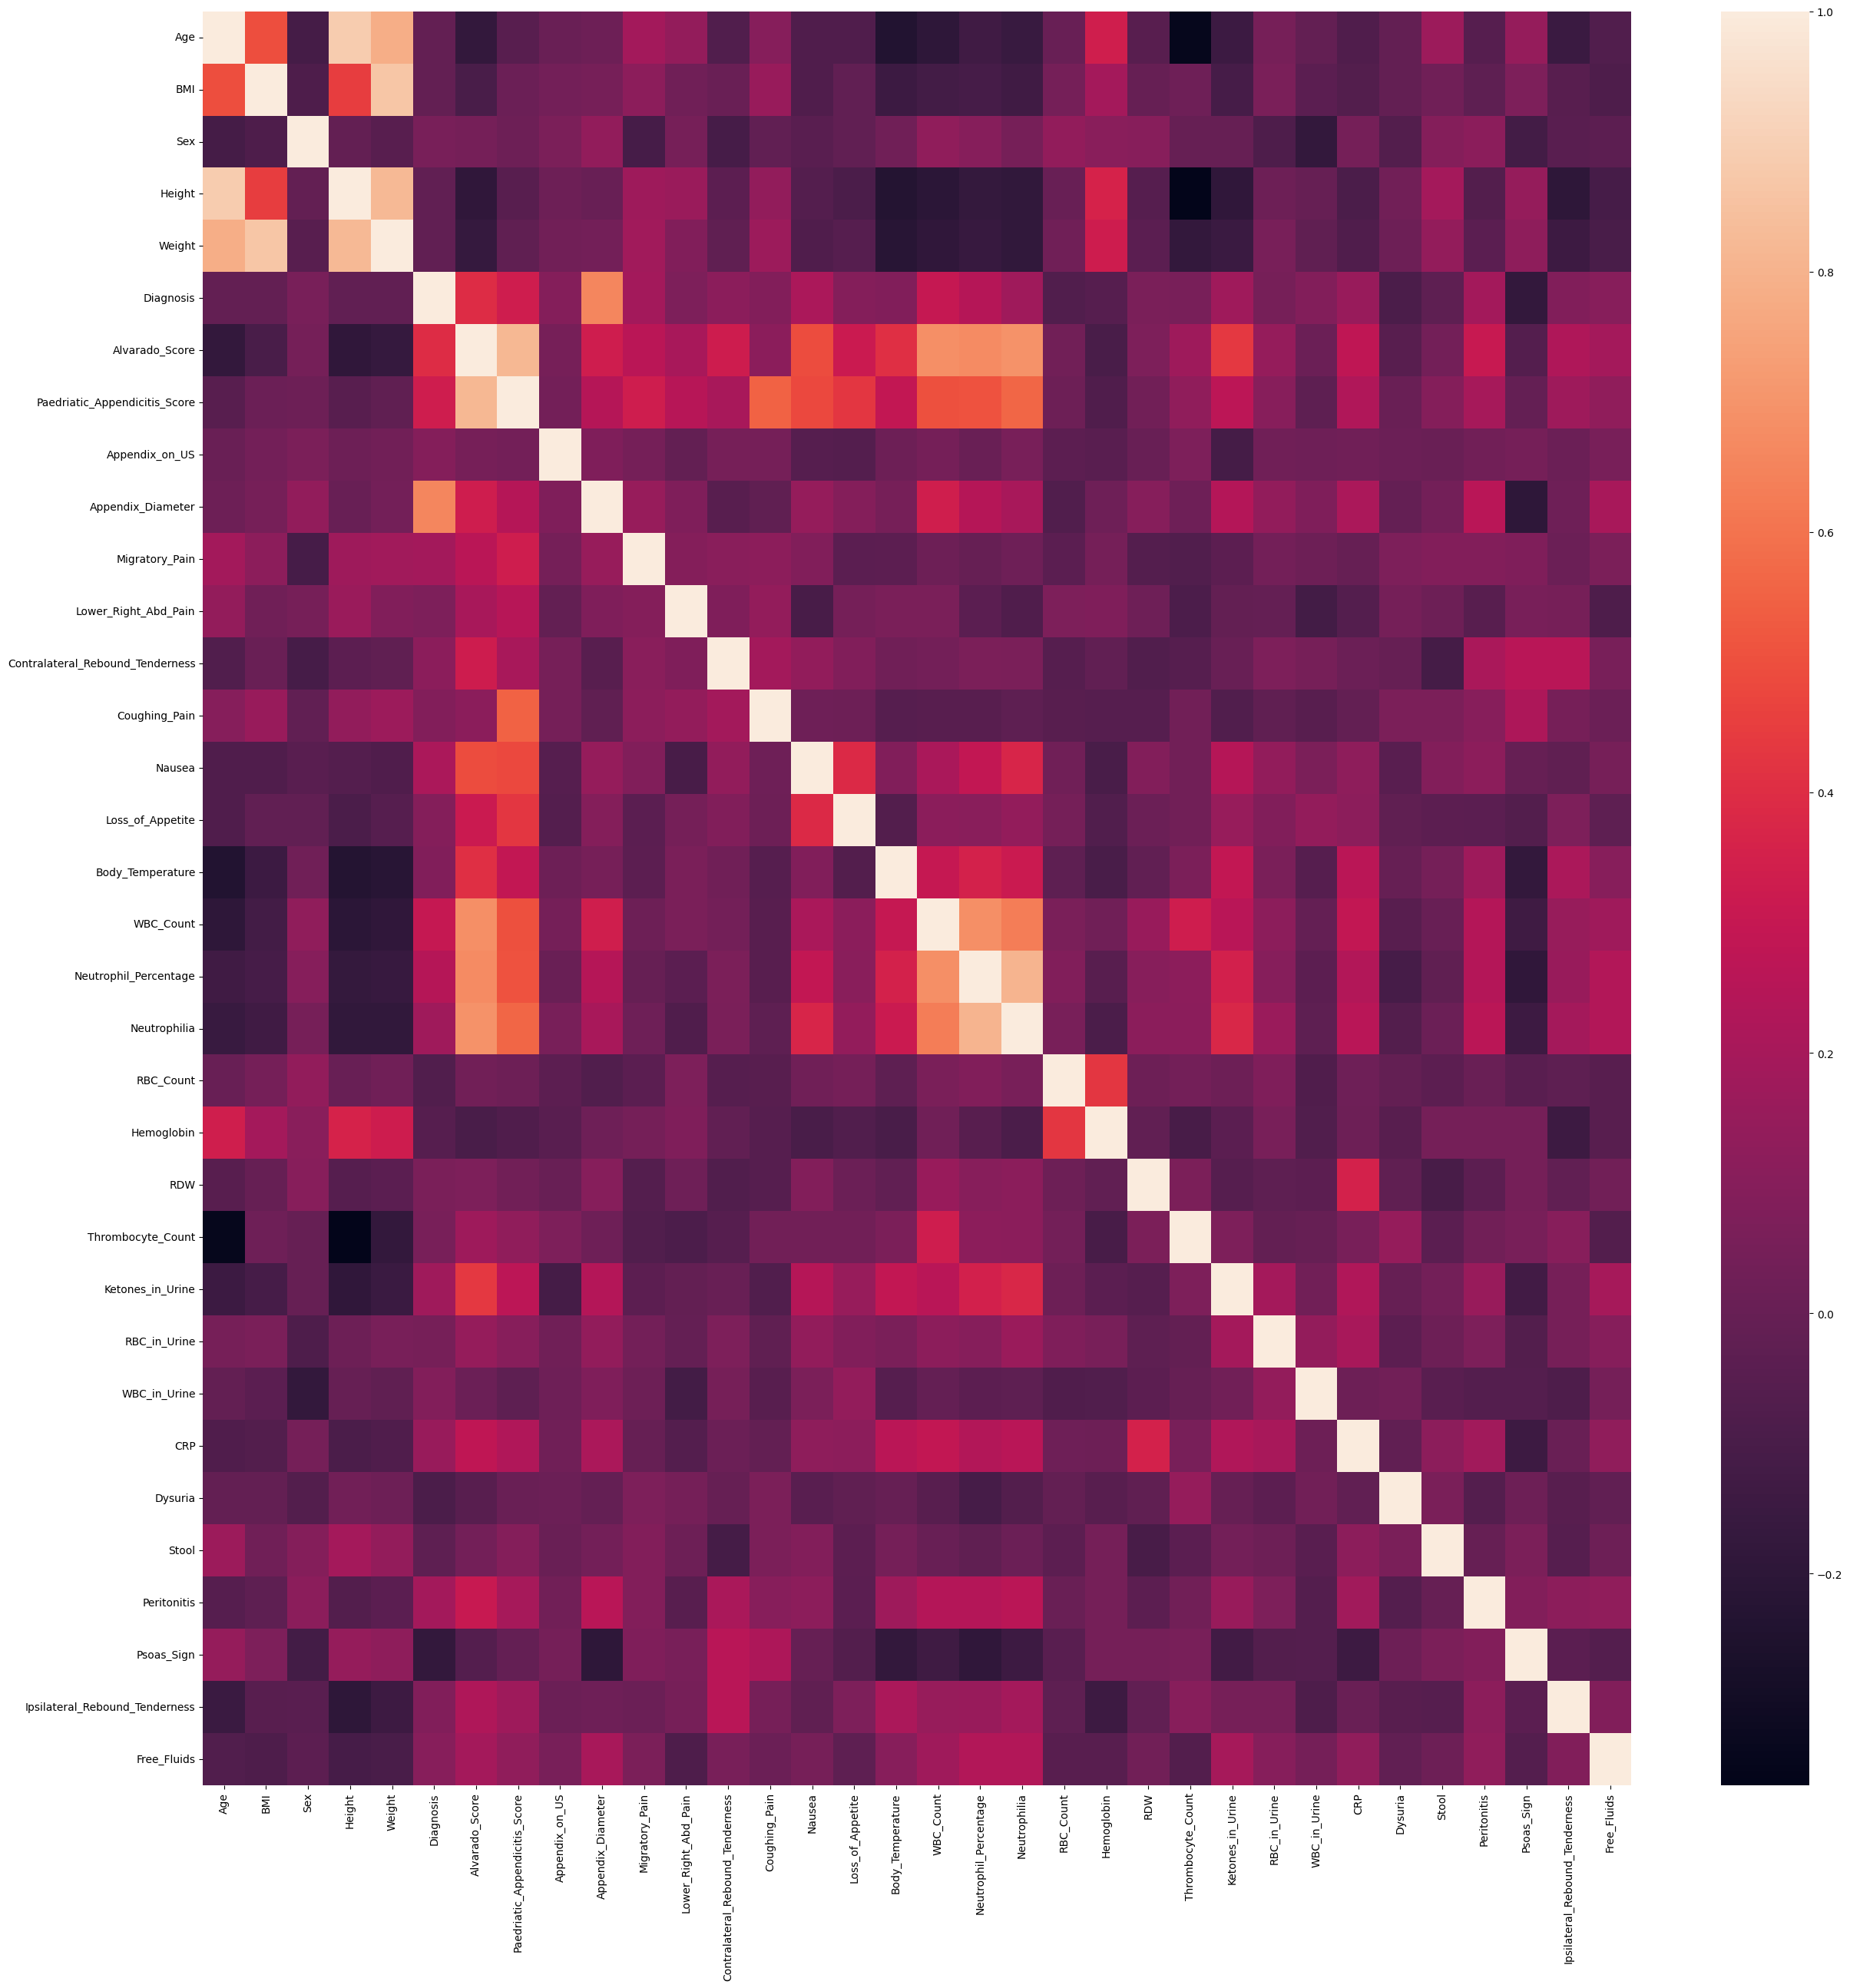

In [89]:
plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())

In [90]:
df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)

In [91]:
df2["Diagnosis"].value_counts()

Diagnosis
1    157
0     81
Name: count, dtype: int64

In [92]:
# dsafsf

In [93]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(238, 33)

In [94]:
from sklearn.model_selection import train_test_split

In [95]:
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [96]:
x_train.shape

(190, 33)

In [97]:
y_train.shape

(190,)

In [98]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.43      0.35      0.39        17
           1       0.68      0.74      0.71        31

    accuracy                           0.60        48
   macro avg       0.55      0.55      0.55        48
weighted avg       0.59      0.60      0.59        48



In [99]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.02 ± 0.00
TEST_ACCURACY - Mean: 0.65 ± 0.08
TEST_F1 - Mean: 0.75 ± 0.07
TEST_ROC_AUC - Mean: 0.61 ± 0.03
TEST_AVERAGE_PRECISION - Mean: 0.72 ± 0.06
TEST_PRECISION - Mean: 0.70 ± 0.07
TEST_RECALL - Mean: 0.81 ± 0.08


In [100]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7210 ± 0.06


In [101]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.56      0.88      0.68        17
           1       0.90      0.61      0.73        31

    accuracy                           0.71        48
   macro avg       0.73      0.75      0.71        48
weighted avg       0.78      0.71      0.71        48



In [102]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.73 ± 0.06
TEST_F1 - Mean: 0.79 ± 0.06
TEST_ROC_AUC - Mean: 0.82 ± 0.05
TEST_AVERAGE_PRECISION - Mean: 0.88 ± 0.07
TEST_PRECISION - Mean: 0.81 ± 0.09
TEST_RECALL - Mean: 0.80 ± 0.12


In [103]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable

X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.8754 ± 0.07


In [104]:
from sklearn.svm import SVC
model = SVC()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.65      1.00      0.78        31

    accuracy                           0.65        48
   macro avg       0.32      0.50      0.39        48
weighted avg       0.42      0.65      0.51        48



C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

In [105]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.66 ± 0.06
TEST_F1 - Mean: 0.79 ± 0.04
TEST_ROC_AUC - Mean: 0.71 ± 0.07
TEST_AVERAGE_PRECISION - Mean: 0.85 ± 0.04
TEST_PRECISION - Mean: 0.66 ± 0.06
TEST_RECALL - Mean: 1.00 ± 0.00


In [106]:
# from sklearn.model_selection import KFold
# from sklearn.metrics import average_precision_score
# import numpy as np

# # Assuming you have your data and model ready
# # X = your_data  # Features
# # y = your_labels  # Target variable

# X = x
# # X = pd.DataFrame(X)
# # y = pd.DataFrame(y)
# def calulatuion():
#     # Initialize KFold with 5 folds
#     kf = KFold(n_splits=5, shuffle=True, random_state=42)

#     aupr_scores = []  # List to store AUPR scores for each fold

#     for train_index, test_index in kf.split(X):
#         X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#         y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#         # Fit your model
#         model.fit(X_train, y_train)

#         # Predict probabilities for positive class
#         y_pred_proba = model.predict_proba(X_test)[:, 1]

#         # Calculate AUPR for this fold
#         aupr = average_precision_score(y_test, y_pred_proba)
#         aupr_scores.append(aupr)

#     # Calculate average AUPR across all folds
#     average_aupr = np.mean(aupr_scores)
#     std_aupr = np.std(aupr_scores)

#     print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
# calulatuion()

In [107]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        17
           1       0.94      0.94      0.94        31

    accuracy                           0.92        48
   macro avg       0.91      0.91      0.91        48
weighted avg       0.92      0.92      0.92        48



In [108]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.98 ± 0.02
TEST_F1 - Mean: 0.99 ± 0.01
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 1.00 ± 0.00
TEST_RECALL - Mean: 0.97 ± 0.02


In [109]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable

X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9723 ± 0.03


In [110]:
y_train.shape

(190,)

In [111]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        17
           1       0.97      0.97      0.97        31

    accuracy                           0.96        48
   macro avg       0.95      0.95      0.95        48
weighted avg       0.96      0.96      0.96        48



In [112]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
X = x
# y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.10 ± 0.01
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.97 ± 0.02
TEST_F1 - Mean: 0.98 ± 0.01
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01


In [113]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable

X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9941 ± 0.00


In [114]:
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
model = XGBClassifier()
model.fit(x_train,y_train,verbose=True)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        17
           1       1.00      0.94      0.97        31

    accuracy                           0.96        48
   macro avg       0.95      0.97      0.96        48
weighted avg       0.96      0.96      0.96        48



In [115]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.05 ± 0.00
SCORE_TIME - Mean: 0.06 ± 0.09
TEST_ACCURACY - Mean: 0.97 ± 0.02
TEST_F1 - Mean: 0.98 ± 0.01
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 1.00 ± 0.00
TEST_PRECISION - Mean: 0.99 ± 0.01
TEST_RECALL - Mean: 0.97 ± 0.02


In [116]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable

# X = x_reduced
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
X = x 
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9960 ± 0.00


In [117]:
from lightgbm import LGBMClassifier
model = LGBMClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

[LightGBM] [Info] Number of positive: 126, number of negative: 64
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 190, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.663158 -> initscore=0.677399
[LightGBM] [Info] Start training from score 0.677399
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [118]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


[LightGBM] [Info] Number of positive: 126, number of negative: 64
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 190, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.663158 -> initscore=0.677399
[LightGBM] [Info] Start training from score 0.677399
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [119]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

[LightGBM] [Info] Number of positive: 126, number of negative: 64
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 190, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.663158 -> initscore=0.677399
[LightGBM] [Info] Start training from score 0.677399
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

[LightGBM] [Info] Number of positive: 126, number of negative: 64
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 190, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.663158 -> initscore=0.677399
[LightGBM] [Info] Start training from score 0.677399
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

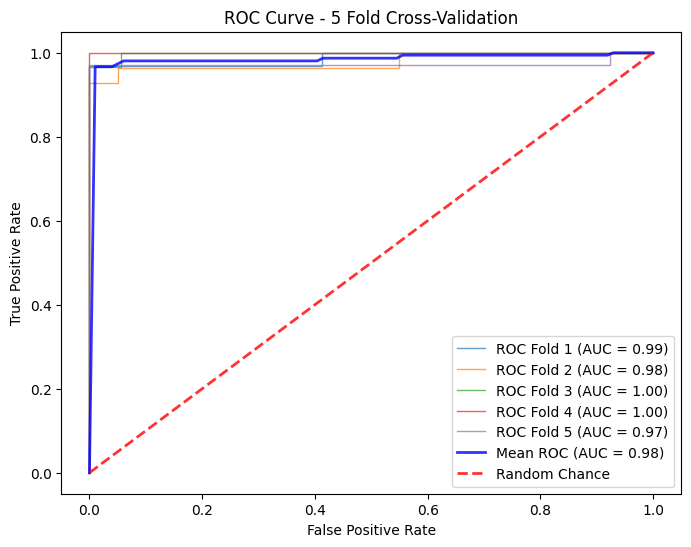

In [120]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
X = x
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [121]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        17
           1       1.00      0.94      0.97        31

    accuracy                           0.96        48
   macro avg       0.95      0.97      0.96        48
weighted avg       0.96      0.96      0.96        48



C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [122]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and w

FIT_TIME - Mean: 0.07 ± 0.03
SCORE_TIME - Mean: 0.02 ± 0.01
TEST_ACCURACY - Mean: 0.97 ± 0.02
TEST_F1 - Mean: 0.98 ± 0.02
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 1.00 ± 0.00
TEST_PRECISION - Mean: 0.99 ± 0.02
TEST_RECALL - Mean: 0.97 ± 0.03


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [123]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.2f} ± {std_aupr:.2f}')
calulatuion()

C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and w

Average AUPR: 1.00 ± 0.00


In [ ]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
X = x
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [ ]:
from catboost import CatBoostClassifier
model =  CatBoostClassifier(iterations=1500, learning_rate=0.01, depth=5, loss_function='Logloss')
model.fit(x_train,y_train, eval_set= (x_test,y_test), verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

In [ ]:
import matplotlib.pyplot as plt    
feature_importance = model.get_feature_importance()
feature_names = x_train.columns 
plt.figure(figsize=(30,30))
plt.bar(feature_names, feature_importance) 
plt.xlabel("Feature Importance") 
plt.title("CatBoost Feature Importance")
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

499:	learn: 0.0211583	total: 775ms	remaining: 1.55s
500:	learn: 0.0210043	total: 778ms	remaining: 1.55s
501:	learn: 0.0209980	total: 779ms	remaining: 1.55s
502:	learn: 0.0209129	total: 781ms	remaining: 1.55s
503:	learn: 0.0208977	total: 782ms	remaining: 1.55s
504:	learn: 0.0208202	total: 784ms	remaining: 1.54s
505:	learn: 0.0208021	total: 785ms	remaining: 1.54s
506:	learn: 0.0207872	total: 787ms	remaining: 1.54s
507:	learn: 0.0206810	total: 789ms	remaining: 1.54s
508:	learn: 0.0206639	total: 790ms	remaining: 1.54s
509:	learn: 0.0206500	total: 792ms	remaining: 1.54s
510:	learn: 0.0206342	total: 794ms	remaining: 1.54s
511:	learn: 0.0204896	total: 796ms	remaining: 1.53s
512:	learn: 0.0204465	total: 797ms	remaining: 1.53s
513:	learn: 0.0203657	total: 798ms	remaining: 1.53s
514:	learn: 0.0202573	total: 800ms	remaining: 1.53s
515:	learn: 0.0202429	total: 801ms	remaining: 1.53s
516:	learn: 0.0201451	total: 803ms	remaining: 1.53s
517:	learn: 0.0200650	total: 805ms	remaining: 1.52s
518:	learn: 

754:	learn: 0.0094739	total: 1.16s	remaining: 1.14s
755:	learn: 0.0094690	total: 1.16s	remaining: 1.14s
756:	learn: 0.0094203	total: 1.16s	remaining: 1.14s
757:	learn: 0.0093721	total: 1.16s	remaining: 1.14s
758:	learn: 0.0093247	total: 1.16s	remaining: 1.14s
759:	learn: 0.0092777	total: 1.17s	remaining: 1.14s
760:	learn: 0.0092311	total: 1.17s	remaining: 1.13s
761:	learn: 0.0092266	total: 1.17s	remaining: 1.13s
762:	learn: 0.0091807	total: 1.17s	remaining: 1.13s
763:	learn: 0.0091352	total: 1.17s	remaining: 1.13s
764:	learn: 0.0091297	total: 1.17s	remaining: 1.13s
765:	learn: 0.0090848	total: 1.18s	remaining: 1.13s
766:	learn: 0.0090401	total: 1.18s	remaining: 1.13s
767:	learn: 0.0089957	total: 1.18s	remaining: 1.12s
768:	learn: 0.0089918	total: 1.18s	remaining: 1.12s
769:	learn: 0.0089480	total: 1.18s	remaining: 1.12s
770:	learn: 0.0089044	total: 1.18s	remaining: 1.12s
771:	learn: 0.0088612	total: 1.19s	remaining: 1.12s
772:	learn: 0.0088185	total: 1.19s	remaining: 1.12s
773:	learn: 

1019:	learn: 0.0047939	total: 1.55s	remaining: 729ms
1020:	learn: 0.0047813	total: 1.55s	remaining: 727ms
1021:	learn: 0.0047686	total: 1.55s	remaining: 726ms
1022:	learn: 0.0047671	total: 1.55s	remaining: 724ms
1023:	learn: 0.0047544	total: 1.55s	remaining: 723ms
1024:	learn: 0.0047419	total: 1.56s	remaining: 721ms
1025:	learn: 0.0047405	total: 1.56s	remaining: 720ms
1026:	learn: 0.0047281	total: 1.56s	remaining: 718ms
1027:	learn: 0.0047266	total: 1.56s	remaining: 717ms
1028:	learn: 0.0047142	total: 1.56s	remaining: 716ms
1029:	learn: 0.0047019	total: 1.56s	remaining: 714ms
1030:	learn: 0.0046897	total: 1.57s	remaining: 713ms
1031:	learn: 0.0046772	total: 1.57s	remaining: 711ms
1032:	learn: 0.0046772	total: 1.57s	remaining: 710ms
1033:	learn: 0.0046761	total: 1.57s	remaining: 708ms
1034:	learn: 0.0046751	total: 1.57s	remaining: 707ms
1035:	learn: 0.0046737	total: 1.57s	remaining: 705ms
1036:	learn: 0.0046617	total: 1.57s	remaining: 703ms
1037:	learn: 0.0046602	total: 1.58s	remaining:

1290:	learn: 0.0033898	total: 1.95s	remaining: 315ms
1291:	learn: 0.0033891	total: 1.95s	remaining: 313ms
1292:	learn: 0.0033828	total: 1.95s	remaining: 312ms
1293:	learn: 0.0033764	total: 1.95s	remaining: 310ms
1294:	learn: 0.0033699	total: 1.95s	remaining: 309ms
1295:	learn: 0.0033695	total: 1.95s	remaining: 307ms
1296:	learn: 0.0033631	total: 1.95s	remaining: 306ms
1297:	learn: 0.0033629	total: 1.96s	remaining: 304ms
1298:	learn: 0.0033566	total: 1.96s	remaining: 303ms
1299:	learn: 0.0033503	total: 1.96s	remaining: 302ms
1300:	learn: 0.0033504	total: 1.96s	remaining: 300ms
1301:	learn: 0.0033441	total: 1.96s	remaining: 299ms
1302:	learn: 0.0033378	total: 1.97s	remaining: 297ms
1303:	learn: 0.0033317	total: 1.97s	remaining: 296ms
1304:	learn: 0.0033312	total: 1.97s	remaining: 294ms
1305:	learn: 0.0033312	total: 1.97s	remaining: 293ms
1306:	learn: 0.0033311	total: 1.97s	remaining: 291ms
1307:	learn: 0.0033305	total: 1.97s	remaining: 290ms
1308:	learn: 0.0033305	total: 1.98s	remaining:

0:	learn: 0.6783646	total: 3.79ms	remaining: 5.68s
1:	learn: 0.6677440	total: 7.65ms	remaining: 5.73s
2:	learn: 0.6567208	total: 11.5ms	remaining: 5.72s
3:	learn: 0.6414480	total: 14.1ms	remaining: 5.29s
4:	learn: 0.6282362	total: 17.9ms	remaining: 5.35s
5:	learn: 0.6170365	total: 19.6ms	remaining: 4.89s
6:	learn: 0.6064434	total: 23ms	remaining: 4.91s
7:	learn: 0.5939022	total: 25.5ms	remaining: 4.75s
8:	learn: 0.5815358	total: 28.7ms	remaining: 4.76s
9:	learn: 0.5678165	total: 32.3ms	remaining: 4.82s
10:	learn: 0.5586151	total: 34.4ms	remaining: 4.66s
11:	learn: 0.5480295	total: 37.1ms	remaining: 4.6s
12:	learn: 0.5397525	total: 40ms	remaining: 4.58s
13:	learn: 0.5310378	total: 43.2ms	remaining: 4.59s
14:	learn: 0.5235302	total: 46.2ms	remaining: 4.57s
15:	learn: 0.5154543	total: 48.1ms	remaining: 4.46s
16:	learn: 0.5087917	total: 49.4ms	remaining: 4.31s
17:	learn: 0.5030858	total: 52.1ms	remaining: 4.29s
18:	learn: 0.4962821	total: 54.9ms	remaining: 4.28s
19:	learn: 0.4871738	total:

...

509:	learn: 0.0235625	total: 1.34s	remaining: 2.61s
510:	learn: 0.0234069	total: 1.35s	remaining: 2.61s
511:	learn: 0.0233170	total: 1.35s	remaining: 2.61s
512:	learn: 0.0231823	total: 1.35s	remaining: 2.6s
513:	learn: 0.0231352	total: 1.36s	remaining: 2.6s
514:	learn: 0.0230226	total: 1.36s	remaining: 2.6s
515:	learn: 0.0229529	total: 1.36s	remaining: 2.6s
516:	learn: 0.0228732	total: 1.36s	remaining: 2.6s
517:	learn: 0.0227858	total: 1.37s	remaining: 2.59s
518:	learn: 0.0227292	total: 1.37s	remaining: 2.59s
519:	learn: 0.0226322	total: 1.37s	remaining: 2.59s
520:	learn: 0.0225353	total: 1.38s	remaining: 2.59s
521:	learn: 0.0224438	total: 1.38s	remaining: 2.59s
522:	learn: 0.0224173	total: 1.39s	remaining: 2.59s
523:	learn: 0.0224031	total: 1.39s	remaining: 2.59s
524:	learn: 0.0223159	total: 1.4s	remaining: 2.59s
525:	learn: 0.0222462	total: 1.4s	remaining: 2.59s
526:	learn: 0.0221559	total: 1.4s	remaining: 2.58s
527:	learn: 0.0220719	total: 1.4s	remaining: 2.58s
528:	learn: 0.0219705

692:	learn: 0.0135027	total: 1.9s	remaining: 2.21s
693:	learn: 0.0135007	total: 1.9s	remaining: 2.21s
694:	learn: 0.0134365	total: 1.91s	remaining: 2.21s
695:	learn: 0.0133980	total: 1.91s	remaining: 2.21s
696:	learn: 0.0133936	total: 1.91s	remaining: 2.2s
697:	learn: 0.0133843	total: 1.92s	remaining: 2.2s
698:	learn: 0.0133793	total: 1.92s	remaining: 2.2s
699:	learn: 0.0133745	total: 1.92s	remaining: 2.2s
700:	learn: 0.0133062	total: 1.93s	remaining: 2.19s
701:	learn: 0.0132634	total: 1.93s	remaining: 2.19s
702:	learn: 0.0132025	total: 1.93s	remaining: 2.19s
703:	learn: 0.0131542	total: 1.93s	remaining: 2.19s
704:	learn: 0.0131497	total: 1.94s	remaining: 2.18s
705:	learn: 0.0131379	total: 1.94s	remaining: 2.18s
706:	learn: 0.0131289	total: 1.94s	remaining: 2.17s
707:	learn: 0.0131239	total: 1.94s	remaining: 2.17s
708:	learn: 0.0130669	total: 1.94s	remaining: 2.17s
709:	learn: 0.0130040	total: 1.95s	remaining: 2.17s
710:	learn: 0.0129572	total: 1.95s	remaining: 2.16s
711:	learn: 0.0129

927:	learn: 0.0085899	total: 2.47s	remaining: 1.52s
928:	learn: 0.0085878	total: 2.47s	remaining: 1.52s
929:	learn: 0.0085676	total: 2.47s	remaining: 1.51s
930:	learn: 0.0085374	total: 2.48s	remaining: 1.51s
931:	learn: 0.0085357	total: 2.48s	remaining: 1.51s
932:	learn: 0.0085179	total: 2.48s	remaining: 1.51s
933:	learn: 0.0085157	total: 2.48s	remaining: 1.51s
934:	learn: 0.0084916	total: 2.49s	remaining: 1.5s
935:	learn: 0.0084717	total: 2.49s	remaining: 1.5s
936:	learn: 0.0084691	total: 2.49s	remaining: 1.5s
937:	learn: 0.0084672	total: 2.49s	remaining: 1.49s
938:	learn: 0.0084434	total: 2.5s	remaining: 1.49s
939:	learn: 0.0084141	total: 2.5s	remaining: 1.49s
940:	learn: 0.0083957	total: 2.5s	remaining: 1.48s
941:	learn: 0.0083933	total: 2.5s	remaining: 1.48s
942:	learn: 0.0083908	total: 2.5s	remaining: 1.48s
943:	learn: 0.0083699	total: 2.5s	remaining: 1.47s
944:	learn: 0.0083687	total: 2.5s	remaining: 1.47s
945:	learn: 0.0083378	total: 2.51s	remaining: 1.47s
946:	learn: 0.0083332	

1154:	learn: 0.0063213	total: 3.07s	remaining: 916ms
1155:	learn: 0.0063100	total: 3.07s	remaining: 914ms
1156:	learn: 0.0062982	total: 3.07s	remaining: 911ms
1157:	learn: 0.0062907	total: 3.08s	remaining: 908ms
1158:	learn: 0.0062893	total: 3.08s	remaining: 906ms
1159:	learn: 0.0062776	total: 3.08s	remaining: 903ms
1160:	learn: 0.0062660	total: 3.08s	remaining: 900ms
1161:	learn: 0.0062544	total: 3.09s	remaining: 898ms
1162:	learn: 0.0062502	total: 3.09s	remaining: 896ms
1163:	learn: 0.0062387	total: 3.09s	remaining: 893ms
1164:	learn: 0.0062377	total: 3.1s	remaining: 891ms
1165:	learn: 0.0062300	total: 3.1s	remaining: 888ms
1166:	learn: 0.0062262	total: 3.1s	remaining: 885ms
1167:	learn: 0.0062148	total: 3.1s	remaining: 883ms
1168:	learn: 0.0062072	total: 3.11s	remaining: 881ms
1169:	learn: 0.0061970	total: 3.11s	remaining: 878ms
1170:	learn: 0.0061858	total: 3.12s	remaining: 875ms
1171:	learn: 0.0061810	total: 3.12s	remaining: 873ms
1172:	learn: 0.0061707	total: 3.12s	remaining: 870

1368:	learn: 0.0049211	total: 3.65s	remaining: 349ms
1369:	learn: 0.0049185	total: 3.65s	remaining: 347ms
1370:	learn: 0.0049154	total: 3.66s	remaining: 344ms
1371:	learn: 0.0049126	total: 3.66s	remaining: 342ms
1372:	learn: 0.0049012	total: 3.66s	remaining: 339ms
1373:	learn: 0.0048898	total: 3.67s	remaining: 336ms
1374:	learn: 0.0048872	total: 3.67s	remaining: 333ms
1375:	learn: 0.0048864	total: 3.67s	remaining: 331ms
1376:	learn: 0.0048833	total: 3.67s	remaining: 328ms
1377:	learn: 0.0048821	total: 3.68s	remaining: 326ms
1378:	learn: 0.0048798	total: 3.68s	remaining: 323ms
1379:	learn: 0.0048772	total: 3.69s	remaining: 321ms
1380:	learn: 0.0048740	total: 3.69s	remaining: 318ms
1381:	learn: 0.0048672	total: 3.69s	remaining: 315ms
1382:	learn: 0.0048666	total: 3.69s	remaining: 313ms
1383:	learn: 0.0048622	total: 3.7s	remaining: 310ms
1384:	learn: 0.0048593	total: 3.7s	remaining: 307ms
1385:	learn: 0.0048560	total: 3.7s	remaining: 305ms
1386:	learn: 0.0048541	total: 3.71s	remaining: 30

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

325:	learn: 0.0382976	total: 875ms	remaining: 3.15s
326:	learn: 0.0382565	total: 878ms	remaining: 3.15s
327:	learn: 0.0382169	total: 881ms	remaining: 3.15s
328:	learn: 0.0379947	total: 884ms	remaining: 3.15s
329:	learn: 0.0378172	total: 888ms	remaining: 3.15s
330:	learn: 0.0377704	total: 891ms	remaining: 3.15s
331:	learn: 0.0377270	total: 896ms	remaining: 3.15s
332:	learn: 0.0376631	total: 898ms	remaining: 3.15s
333:	learn: 0.0373365	total: 900ms	remaining: 3.14s
334:	learn: 0.0372172	total: 903ms	remaining: 3.14s
335:	learn: 0.0371066	total: 905ms	remaining: 3.13s
336:	learn: 0.0368954	total: 907ms	remaining: 3.13s
337:	learn: 0.0367826	total: 909ms	remaining: 3.13s
338:	learn: 0.0366434	total: 912ms	remaining: 3.12s
339:	learn: 0.0364999	total: 914ms	remaining: 3.12s
340:	learn: 0.0363928	total: 916ms	remaining: 3.12s
341:	learn: 0.0362176	total: 919ms	remaining: 3.11s
342:	learn: 0.0359817	total: 922ms	remaining: 3.11s
343:	learn: 0.0359676	total: 924ms	remaining: 3.1s
344:	learn: 0

515:	learn: 0.0202429	total: 1.27s	remaining: 2.42s
516:	learn: 0.0201451	total: 1.27s	remaining: 2.42s
517:	learn: 0.0200650	total: 1.27s	remaining: 2.42s
518:	learn: 0.0200496	total: 1.28s	remaining: 2.42s
519:	learn: 0.0199683	total: 1.28s	remaining: 2.41s
520:	learn: 0.0198409	total: 1.28s	remaining: 2.41s
521:	learn: 0.0198259	total: 1.28s	remaining: 2.41s
522:	learn: 0.0197314	total: 1.29s	remaining: 2.4s
523:	learn: 0.0195930	total: 1.29s	remaining: 2.4s
524:	learn: 0.0195782	total: 1.29s	remaining: 2.4s
525:	learn: 0.0194769	total: 1.29s	remaining: 2.4s
526:	learn: 0.0194112	total: 1.3s	remaining: 2.4s
527:	learn: 0.0193979	total: 1.3s	remaining: 2.39s
528:	learn: 0.0192768	total: 1.3s	remaining: 2.39s
529:	learn: 0.0192641	total: 1.31s	remaining: 2.39s
530:	learn: 0.0191530	total: 1.31s	remaining: 2.39s
531:	learn: 0.0191398	total: 1.31s	remaining: 2.39s
532:	learn: 0.0190381	total: 1.32s	remaining: 2.39s
533:	learn: 0.0189378	total: 1.32s	remaining: 2.39s
534:	learn: 0.018845

698:	learn: 0.0113408	total: 1.77s	remaining: 2.03s
699:	learn: 0.0113269	total: 1.78s	remaining: 2.03s
700:	learn: 0.0113221	total: 1.78s	remaining: 2.03s
701:	learn: 0.0113170	total: 1.78s	remaining: 2.03s
702:	learn: 0.0112500	total: 1.79s	remaining: 2.03s
703:	learn: 0.0111833	total: 1.79s	remaining: 2.03s
704:	learn: 0.0111365	total: 1.79s	remaining: 2.02s
705:	learn: 0.0110711	total: 1.8s	remaining: 2.02s
706:	learn: 0.0110267	total: 1.8s	remaining: 2.02s
707:	learn: 0.0109625	total: 1.81s	remaining: 2.02s
708:	learn: 0.0109576	total: 1.81s	remaining: 2.02s
709:	learn: 0.0109516	total: 1.81s	remaining: 2.02s
710:	learn: 0.0109464	total: 1.81s	remaining: 2.01s
711:	learn: 0.0109414	total: 1.82s	remaining: 2.01s
712:	learn: 0.0108778	total: 1.82s	remaining: 2.01s
713:	learn: 0.0108733	total: 1.82s	remaining: 2s
714:	learn: 0.0108297	total: 1.82s	remaining: 2s
715:	learn: 0.0108238	total: 1.83s	remaining: 2s
716:	learn: 0.0107619	total: 1.83s	remaining: 2s
717:	learn: 0.0107564	tota

866:	learn: 0.0066329	total: 2.23s	remaining: 1.63s
867:	learn: 0.0066085	total: 2.23s	remaining: 1.63s
868:	learn: 0.0065844	total: 2.24s	remaining: 1.62s
869:	learn: 0.0065605	total: 2.24s	remaining: 1.62s
870:	learn: 0.0065580	total: 2.24s	remaining: 1.62s
871:	learn: 0.0065554	total: 2.24s	remaining: 1.61s
872:	learn: 0.0065318	total: 2.25s	remaining: 1.61s
873:	learn: 0.0065083	total: 2.25s	remaining: 1.61s
874:	learn: 0.0064848	total: 2.25s	remaining: 1.61s
875:	learn: 0.0064618	total: 2.25s	remaining: 1.61s
876:	learn: 0.0064388	total: 2.26s	remaining: 1.6s
877:	learn: 0.0064160	total: 2.26s	remaining: 1.6s
878:	learn: 0.0063932	total: 2.27s	remaining: 1.6s
879:	learn: 0.0063709	total: 2.27s	remaining: 1.6s
880:	learn: 0.0063685	total: 2.27s	remaining: 1.59s
881:	learn: 0.0063462	total: 2.27s	remaining: 1.59s
882:	learn: 0.0063240	total: 2.27s	remaining: 1.59s
883:	learn: 0.0063020	total: 2.27s	remaining: 1.58s
884:	learn: 0.0062802	total: 2.28s	remaining: 1.58s
885:	learn: 0.00

1071:	learn: 0.0044167	total: 2.74s	remaining: 1.09s
1072:	learn: 0.0044057	total: 2.74s	remaining: 1.09s
1073:	learn: 0.0044057	total: 2.74s	remaining: 1.09s
1074:	learn: 0.0043950	total: 2.75s	remaining: 1.08s
1075:	learn: 0.0043844	total: 2.75s	remaining: 1.08s
1076:	learn: 0.0043830	total: 2.75s	remaining: 1.08s
1077:	learn: 0.0043723	total: 2.75s	remaining: 1.08s
1078:	learn: 0.0043618	total: 2.76s	remaining: 1.07s
1079:	learn: 0.0043513	total: 2.76s	remaining: 1.07s
1080:	learn: 0.0043501	total: 2.76s	remaining: 1.07s
1081:	learn: 0.0043496	total: 2.77s	remaining: 1.07s
1082:	learn: 0.0043393	total: 2.77s	remaining: 1.07s
1083:	learn: 0.0043380	total: 2.77s	remaining: 1.06s
1084:	learn: 0.0043277	total: 2.77s	remaining: 1.06s
1085:	learn: 0.0043172	total: 2.78s	remaining: 1.06s
1086:	learn: 0.0043162	total: 2.78s	remaining: 1.05s
1087:	learn: 0.0043056	total: 2.78s	remaining: 1.05s
1088:	learn: 0.0042954	total: 2.78s	remaining: 1.05s
1089:	learn: 0.0042943	total: 2.78s	remaining:

...

773:	learn: 0.0113500	total: 1.55s	remaining: 1.45s
774:	learn: 0.0113467	total: 1.55s	remaining: 1.45s
775:	learn: 0.0113335	total: 1.56s	remaining: 1.45s
776:	learn: 0.0113300	total: 1.56s	remaining: 1.45s
777:	learn: 0.0113269	total: 1.56s	remaining: 1.45s
778:	learn: 0.0113229	total: 1.57s	remaining: 1.45s
779:	learn: 0.0112793	total: 1.57s	remaining: 1.45s
780:	learn: 0.0112508	total: 1.58s	remaining: 1.45s
781:	learn: 0.0112375	total: 1.58s	remaining: 1.45s
782:	learn: 0.0112293	total: 1.58s	remaining: 1.45s
783:	learn: 0.0111885	total: 1.58s	remaining: 1.45s
784:	learn: 0.0111853	total: 1.59s	remaining: 1.45s
785:	learn: 0.0111831	total: 1.59s	remaining: 1.45s
786:	learn: 0.0111404	total: 1.59s	remaining: 1.45s
787:	learn: 0.0111101	total: 1.6s	remaining: 1.44s
788:	learn: 0.0111031	total: 1.6s	remaining: 1.44s
789:	learn: 0.0111011	total: 1.6s	remaining: 1.44s
790:	learn: 0.0110913	total: 1.6s	remaining: 1.44s
791:	learn: 0.0110876	total: 1.6s	remaining: 1.43s
792:	learn: 0.011

969:	learn: 0.0080986	total: 1.93s	remaining: 1.05s
970:	learn: 0.0080940	total: 1.93s	remaining: 1.05s
971:	learn: 0.0080722	total: 1.94s	remaining: 1.05s
972:	learn: 0.0080508	total: 1.94s	remaining: 1.05s
973:	learn: 0.0080337	total: 1.95s	remaining: 1.05s
974:	learn: 0.0080273	total: 1.95s	remaining: 1.05s
975:	learn: 0.0080005	total: 1.95s	remaining: 1.05s
976:	learn: 0.0079796	total: 1.96s	remaining: 1.05s
977:	learn: 0.0079751	total: 1.96s	remaining: 1.04s
978:	learn: 0.0079732	total: 1.96s	remaining: 1.04s
979:	learn: 0.0079672	total: 1.97s	remaining: 1.04s
980:	learn: 0.0079654	total: 1.97s	remaining: 1.04s
981:	learn: 0.0079614	total: 1.97s	remaining: 1.04s
982:	learn: 0.0079424	total: 1.98s	remaining: 1.04s
983:	learn: 0.0079214	total: 1.98s	remaining: 1.04s
984:	learn: 0.0078953	total: 1.98s	remaining: 1.04s
985:	learn: 0.0078746	total: 1.99s	remaining: 1.03s
986:	learn: 0.0078542	total: 1.99s	remaining: 1.03s
987:	learn: 0.0078529	total: 1.99s	remaining: 1.03s
988:	learn: 

1157:	learn: 0.0062907	total: 2.32s	remaining: 685ms
1158:	learn: 0.0062893	total: 2.32s	remaining: 683ms
1159:	learn: 0.0062776	total: 2.32s	remaining: 681ms
1160:	learn: 0.0062660	total: 2.33s	remaining: 679ms
1161:	learn: 0.0062544	total: 2.33s	remaining: 678ms
1162:	learn: 0.0062502	total: 2.33s	remaining: 676ms
1163:	learn: 0.0062387	total: 2.34s	remaining: 674ms
1164:	learn: 0.0062377	total: 2.34s	remaining: 672ms
1165:	learn: 0.0062300	total: 2.34s	remaining: 670ms
1166:	learn: 0.0062262	total: 2.34s	remaining: 668ms
1167:	learn: 0.0062148	total: 2.34s	remaining: 666ms
1168:	learn: 0.0062072	total: 2.35s	remaining: 664ms
1169:	learn: 0.0061970	total: 2.35s	remaining: 662ms
1170:	learn: 0.0061858	total: 2.35s	remaining: 660ms
1171:	learn: 0.0061810	total: 2.35s	remaining: 658ms
1172:	learn: 0.0061707	total: 2.35s	remaining: 656ms
1173:	learn: 0.0061617	total: 2.35s	remaining: 654ms
1174:	learn: 0.0061577	total: 2.36s	remaining: 652ms
1175:	learn: 0.0061466	total: 2.36s	remaining:

1341:	learn: 0.0050494	total: 2.71s	remaining: 320ms
1342:	learn: 0.0050427	total: 2.72s	remaining: 318ms
1343:	learn: 0.0050394	total: 2.72s	remaining: 316ms
1344:	learn: 0.0050317	total: 2.73s	remaining: 314ms
1345:	learn: 0.0050300	total: 2.73s	remaining: 312ms
1346:	learn: 0.0050180	total: 2.73s	remaining: 310ms
1347:	learn: 0.0050152	total: 2.73s	remaining: 309ms
1348:	learn: 0.0050033	total: 2.74s	remaining: 307ms
1349:	learn: 0.0049969	total: 2.74s	remaining: 305ms
1350:	learn: 0.0049960	total: 2.74s	remaining: 303ms
1351:	learn: 0.0049934	total: 2.75s	remaining: 301ms
1352:	learn: 0.0049925	total: 2.75s	remaining: 299ms
1353:	learn: 0.0049808	total: 2.75s	remaining: 296ms
1354:	learn: 0.0049795	total: 2.75s	remaining: 294ms
1355:	learn: 0.0049729	total: 2.75s	remaining: 292ms
1356:	learn: 0.0049704	total: 2.75s	remaining: 290ms
1357:	learn: 0.0049692	total: 2.76s	remaining: 288ms
1358:	learn: 0.0049663	total: 2.76s	remaining: 286ms
1359:	learn: 0.0049632	total: 2.76s	remaining:

Average AUPR: 0.9948 ± 0.00


731:	learn: 0.0102124	total: 1.56s	remaining: 1.64s
732:	learn: 0.0101849	total: 1.56s	remaining: 1.64s
733:	learn: 0.0101804	total: 1.57s	remaining: 1.64s
734:	learn: 0.0101752	total: 1.57s	remaining: 1.64s
735:	learn: 0.0101194	total: 1.57s	remaining: 1.63s
736:	learn: 0.0100645	total: 1.58s	remaining: 1.63s
737:	learn: 0.0100104	total: 1.58s	remaining: 1.63s
738:	learn: 0.0099566	total: 1.58s	remaining: 1.63s
739:	learn: 0.0099034	total: 1.58s	remaining: 1.63s
740:	learn: 0.0098509	total: 1.58s	remaining: 1.62s
741:	learn: 0.0098108	total: 1.59s	remaining: 1.62s
742:	learn: 0.0097755	total: 1.59s	remaining: 1.62s
743:	learn: 0.0097716	total: 1.59s	remaining: 1.62s
744:	learn: 0.0097658	total: 1.59s	remaining: 1.61s
745:	learn: 0.0097616	total: 1.59s	remaining: 1.61s
746:	learn: 0.0097100	total: 1.6s	remaining: 1.61s
747:	learn: 0.0096594	total: 1.6s	remaining: 1.61s
748:	learn: 0.0096551	total: 1.6s	remaining: 1.6s
749:	learn: 0.0096048	total: 1.6s	remaining: 1.6s
750:	learn: 0.0095

923:	learn: 0.0057524	total: 1.94s	remaining: 1.21s
924:	learn: 0.0057342	total: 1.94s	remaining: 1.21s
925:	learn: 0.0057325	total: 1.95s	remaining: 1.21s
926:	learn: 0.0057303	total: 1.95s	remaining: 1.21s
927:	learn: 0.0057121	total: 1.96s	remaining: 1.21s
928:	learn: 0.0056941	total: 1.96s	remaining: 1.2s
929:	learn: 0.0056763	total: 1.96s	remaining: 1.2s
930:	learn: 0.0056584	total: 1.96s	remaining: 1.2s
931:	learn: 0.0056564	total: 1.96s	remaining: 1.2s
932:	learn: 0.0056542	total: 1.97s	remaining: 1.19s
933:	learn: 0.0056365	total: 1.97s	remaining: 1.19s
934:	learn: 0.0056346	total: 1.97s	remaining: 1.19s
935:	learn: 0.0056172	total: 1.97s	remaining: 1.19s
936:	learn: 0.0055999	total: 1.97s	remaining: 1.19s
937:	learn: 0.0055979	total: 1.97s	remaining: 1.18s
938:	learn: 0.0055954	total: 1.98s	remaining: 1.18s
939:	learn: 0.0055782	total: 1.98s	remaining: 1.18s
940:	learn: 0.0055610	total: 1.98s	remaining: 1.18s
941:	learn: 0.0055589	total: 1.98s	remaining: 1.17s
942:	learn: 0.00

1115:	learn: 0.0041284	total: 2.34s	remaining: 805ms
1116:	learn: 0.0041273	total: 2.34s	remaining: 803ms
1117:	learn: 0.0041273	total: 2.34s	remaining: 801ms
1118:	learn: 0.0041261	total: 2.35s	remaining: 799ms
1119:	learn: 0.0041168	total: 2.35s	remaining: 798ms
1120:	learn: 0.0041159	total: 2.35s	remaining: 796ms
1121:	learn: 0.0041064	total: 2.35s	remaining: 794ms
1122:	learn: 0.0040971	total: 2.36s	remaining: 791ms
1123:	learn: 0.0040961	total: 2.36s	remaining: 789ms
1124:	learn: 0.0040867	total: 2.36s	remaining: 787ms
1125:	learn: 0.0040860	total: 2.36s	remaining: 785ms
1126:	learn: 0.0040768	total: 2.37s	remaining: 783ms
1127:	learn: 0.0040767	total: 2.37s	remaining: 781ms
1128:	learn: 0.0040673	total: 2.37s	remaining: 779ms
1129:	learn: 0.0040663	total: 2.37s	remaining: 777ms
1130:	learn: 0.0040571	total: 2.37s	remaining: 774ms
1131:	learn: 0.0040480	total: 2.37s	remaining: 772ms
1132:	learn: 0.0040389	total: 2.38s	remaining: 770ms
1133:	learn: 0.0040379	total: 2.38s	remaining:

1275:	learn: 0.0034250	total: 2.73s	remaining: 479ms
1276:	learn: 0.0034246	total: 2.73s	remaining: 477ms
1277:	learn: 0.0034180	total: 2.74s	remaining: 475ms
1278:	learn: 0.0034180	total: 2.74s	remaining: 473ms
1279:	learn: 0.0034181	total: 2.74s	remaining: 471ms
1280:	learn: 0.0034116	total: 2.74s	remaining: 469ms
1281:	learn: 0.0034115	total: 2.75s	remaining: 467ms
1282:	learn: 0.0034116	total: 2.75s	remaining: 465ms
1283:	learn: 0.0034116	total: 2.75s	remaining: 463ms
1284:	learn: 0.0034111	total: 2.75s	remaining: 460ms
1285:	learn: 0.0034104	total: 2.75s	remaining: 458ms
1286:	learn: 0.0034040	total: 2.75s	remaining: 456ms
1287:	learn: 0.0033975	total: 2.76s	remaining: 454ms
1288:	learn: 0.0033911	total: 2.76s	remaining: 452ms
1289:	learn: 0.0033905	total: 2.76s	remaining: 449ms
1290:	learn: 0.0033898	total: 2.76s	remaining: 447ms
1291:	learn: 0.0033891	total: 2.76s	remaining: 445ms
1292:	learn: 0.0033828	total: 2.77s	remaining: 443ms
1293:	learn: 0.0033764	total: 2.77s	remaining:

1435:	learn: 0.0030756	total: 3.1s	remaining: 138ms
1436:	learn: 0.0030754	total: 3.1s	remaining: 136ms
1437:	learn: 0.0030702	total: 3.11s	remaining: 134ms
1438:	learn: 0.0030702	total: 3.11s	remaining: 132ms
1439:	learn: 0.0030649	total: 3.11s	remaining: 130ms
1440:	learn: 0.0030649	total: 3.12s	remaining: 128ms
1441:	learn: 0.0030645	total: 3.12s	remaining: 125ms
1442:	learn: 0.0030644	total: 3.12s	remaining: 123ms
1443:	learn: 0.0030643	total: 3.12s	remaining: 121ms
1444:	learn: 0.0030592	total: 3.12s	remaining: 119ms
1445:	learn: 0.0030540	total: 3.13s	remaining: 117ms
1446:	learn: 0.0030535	total: 3.13s	remaining: 115ms
1447:	learn: 0.0030534	total: 3.13s	remaining: 112ms
1448:	learn: 0.0030481	total: 3.13s	remaining: 110ms
1449:	learn: 0.0030478	total: 3.13s	remaining: 108ms
1450:	learn: 0.0030426	total: 3.14s	remaining: 106ms
1451:	learn: 0.0030426	total: 3.14s	remaining: 104ms
1452:	learn: 0.0030419	total: 3.14s	remaining: 102ms
1453:	learn: 0.0030414	total: 3.14s	remaining: 9

...

697:	learn: 0.0133843	total: 1.41s	remaining: 1.62s
698:	learn: 0.0133793	total: 1.41s	remaining: 1.62s
699:	learn: 0.0133745	total: 1.42s	remaining: 1.62s
700:	learn: 0.0133062	total: 1.42s	remaining: 1.62s
701:	learn: 0.0132634	total: 1.42s	remaining: 1.61s
702:	learn: 0.0132025	total: 1.42s	remaining: 1.61s
703:	learn: 0.0131542	total: 1.43s	remaining: 1.61s
704:	learn: 0.0131497	total: 1.43s	remaining: 1.61s
705:	learn: 0.0131379	total: 1.43s	remaining: 1.61s
706:	learn: 0.0131289	total: 1.43s	remaining: 1.61s
707:	learn: 0.0131239	total: 1.44s	remaining: 1.6s
708:	learn: 0.0130669	total: 1.44s	remaining: 1.6s
709:	learn: 0.0130040	total: 1.44s	remaining: 1.6s
710:	learn: 0.0129572	total: 1.44s	remaining: 1.6s
711:	learn: 0.0129515	total: 1.44s	remaining: 1.6s
712:	learn: 0.0129040	total: 1.45s	remaining: 1.6s
713:	learn: 0.0128648	total: 1.45s	remaining: 1.6s
714:	learn: 0.0128023	total: 1.46s	remaining: 1.6s
715:	learn: 0.0127944	total: 1.46s	remaining: 1.6s
716:	learn: 0.0127803

874:	learn: 0.0092942	total: 1.8s	remaining: 1.29s
875:	learn: 0.0092588	total: 1.81s	remaining: 1.29s
876:	learn: 0.0092295	total: 1.81s	remaining: 1.29s
877:	learn: 0.0092238	total: 1.82s	remaining: 1.29s
878:	learn: 0.0091890	total: 1.82s	remaining: 1.29s
879:	learn: 0.0091669	total: 1.82s	remaining: 1.28s
880:	learn: 0.0091637	total: 1.82s	remaining: 1.28s
881:	learn: 0.0091619	total: 1.83s	remaining: 1.28s
882:	learn: 0.0091543	total: 1.83s	remaining: 1.28s
883:	learn: 0.0091516	total: 1.83s	remaining: 1.28s
884:	learn: 0.0091174	total: 1.83s	remaining: 1.27s
885:	learn: 0.0091155	total: 1.84s	remaining: 1.27s
886:	learn: 0.0090814	total: 1.84s	remaining: 1.27s
887:	learn: 0.0090791	total: 1.84s	remaining: 1.27s
888:	learn: 0.0090727	total: 1.84s	remaining: 1.27s
889:	learn: 0.0090496	total: 1.84s	remaining: 1.26s
890:	learn: 0.0090160	total: 1.84s	remaining: 1.26s
891:	learn: 0.0090077	total: 1.85s	remaining: 1.26s
892:	learn: 0.0089804	total: 1.85s	remaining: 1.26s
893:	learn: 0

1066:	learn: 0.0070521	total: 2.2s	remaining: 894ms
1067:	learn: 0.0070477	total: 2.2s	remaining: 892ms
1068:	learn: 0.0070319	total: 2.21s	remaining: 890ms
1069:	learn: 0.0070193	total: 2.21s	remaining: 889ms
1070:	learn: 0.0070176	total: 2.21s	remaining: 887ms
1071:	learn: 0.0070162	total: 2.22s	remaining: 885ms
1072:	learn: 0.0070143	total: 2.22s	remaining: 883ms
1073:	learn: 0.0070097	total: 2.22s	remaining: 881ms
1074:	learn: 0.0070081	total: 2.22s	remaining: 879ms
1075:	learn: 0.0069953	total: 2.23s	remaining: 877ms
1076:	learn: 0.0069826	total: 2.23s	remaining: 875ms
1077:	learn: 0.0069812	total: 2.23s	remaining: 873ms
1078:	learn: 0.0069791	total: 2.23s	remaining: 870ms
1079:	learn: 0.0069777	total: 2.23s	remaining: 868ms
1080:	learn: 0.0069760	total: 2.23s	remaining: 866ms
1081:	learn: 0.0069610	total: 2.23s	remaining: 864ms
1082:	learn: 0.0069482	total: 2.24s	remaining: 862ms
1083:	learn: 0.0069469	total: 2.24s	remaining: 860ms
1084:	learn: 0.0069426	total: 2.24s	remaining: 8

1255:	learn: 0.0055904	total: 2.59s	remaining: 504ms
1256:	learn: 0.0055819	total: 2.6s	remaining: 502ms
1257:	learn: 0.0055672	total: 2.6s	remaining: 500ms
1258:	learn: 0.0055587	total: 2.6s	remaining: 498ms
1259:	learn: 0.0055441	total: 2.61s	remaining: 496ms
1260:	learn: 0.0055409	total: 2.61s	remaining: 495ms
1261:	learn: 0.0055357	total: 2.61s	remaining: 493ms
1262:	learn: 0.0055301	total: 2.61s	remaining: 491ms
1263:	learn: 0.0055214	total: 2.62s	remaining: 488ms
1264:	learn: 0.0055182	total: 2.62s	remaining: 486ms
1265:	learn: 0.0055143	total: 2.62s	remaining: 484ms
1266:	learn: 0.0055082	total: 2.62s	remaining: 482ms
1267:	learn: 0.0055014	total: 2.62s	remaining: 480ms
1268:	learn: 0.0054929	total: 2.62s	remaining: 478ms
1269:	learn: 0.0054847	total: 2.63s	remaining: 476ms
1270:	learn: 0.0054764	total: 2.63s	remaining: 474ms
1271:	learn: 0.0054711	total: 2.63s	remaining: 472ms
1272:	learn: 0.0054627	total: 2.63s	remaining: 469ms
1273:	learn: 0.0054596	total: 2.63s	remaining: 46

1432:	learn: 0.0046636	total: 2.98s	remaining: 139ms
1433:	learn: 0.0046608	total: 2.98s	remaining: 137ms
1434:	learn: 0.0046588	total: 2.98s	remaining: 135ms
1435:	learn: 0.0046566	total: 2.99s	remaining: 133ms
1436:	learn: 0.0046536	total: 2.99s	remaining: 131ms
1437:	learn: 0.0046508	total: 3s	remaining: 129ms
1438:	learn: 0.0046403	total: 3s	remaining: 127ms
1439:	learn: 0.0046382	total: 3s	remaining: 125ms
1440:	learn: 0.0046342	total: 3s	remaining: 123ms
1441:	learn: 0.0046342	total: 3s	remaining: 121ms
1442:	learn: 0.0046314	total: 3.01s	remaining: 119ms
1443:	learn: 0.0046284	total: 3.01s	remaining: 117ms
1444:	learn: 0.0046224	total: 3.01s	remaining: 115ms
1445:	learn: 0.0046197	total: 3.01s	remaining: 113ms
1446:	learn: 0.0046170	total: 3.02s	remaining: 110ms
1447:	learn: 0.0046147	total: 3.02s	remaining: 108ms
1448:	learn: 0.0046120	total: 3.02s	remaining: 106ms
1449:	learn: 0.0046075	total: 3.02s	remaining: 104ms
1450:	learn: 0.0046021	total: 3.02s	remaining: 102ms
1451:	le

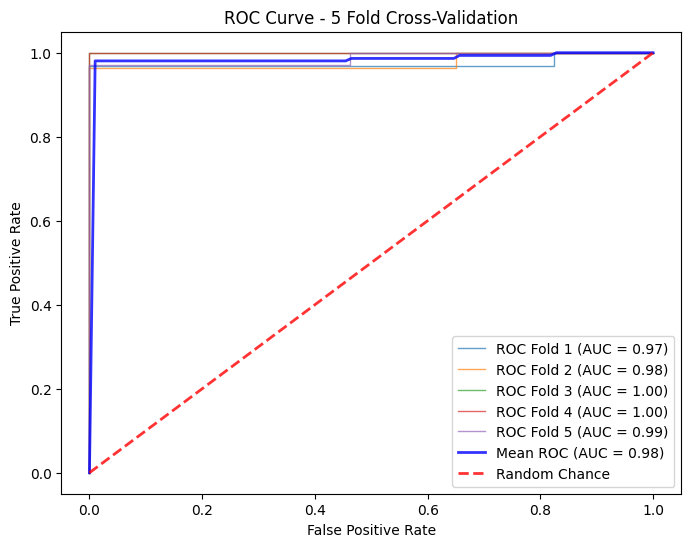

In [ ]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
X = x
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
# # y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [ ]:
# from sklearn.model_selection import KFold
# from sklearn.metrics import average_precision_score
# import numpy as np

# # Assuming you have your data and model ready
# # X = your_data  # Features
# # y = your_labels  # Target variable

# # X = x_reduced
# # X = pd.DataFrame(X)
# # y = pd.DataFrame(y)

# # Initialize KFold with 5 folds
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# aupr_scores = []  # List to store AUPR scores for each fold

# for train_index, test_index in kf.split(X):
#     X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
#     # Fit your model
#     model.fit(X_train, y_train)
    
#     # Predict probabilities for positive class
#     y_pred_proba = model.predict_proba(X_test)[:, 1]
    
#     # Calculate AUPR for this fold
#     aupr = average_precision_score(y_test, y_pred_proba)
#     aupr_scores.append(aupr)

# # Calculate average AUPR across all folds
# average_aupr = np.mean(aupr_scores)
# std_aupr = np.std(aupr_scores)

# print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')


# Dimensionlaity Reduction and Feature Selection Techniques

In [107]:
# !pip install boruta

In [108]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(x,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(x), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", X.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              X.columns[i], " - Ranking: ", feat_selector.ranking_[i])

Iteration: 	1 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	2 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	3 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	4 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	5 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	6 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	7 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	8 / 10
Confirmed: 	4
Tentative: 	1
Rejected: 	27
Iteration: 	9 / 10
Confirmed: 	4
Tentative: 	1
Rejected: 	27


BorutaPy finished running.

Iteration: 	10 / 10
Confirmed: 	4
Tentative: 	0
Rejected: 	27

------Support and Ranking for each feature------
Doesn't pass the test:  Age  - Ranking:  15
Doesn't pass the test:  BMI  - Ranking:  5
Doesn't pass the test:  Sex  - Ranking:  26
Doesn't pass the test:  Height  - Ranking:  11
Doesn't pass the test:  Weight  - Ranking:  5
Passes the test:  Alvarado_Score  - Ranking:  1
Passes the test:  Paedriatic_Appendic

In [109]:
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)

<AxesSubplot: >

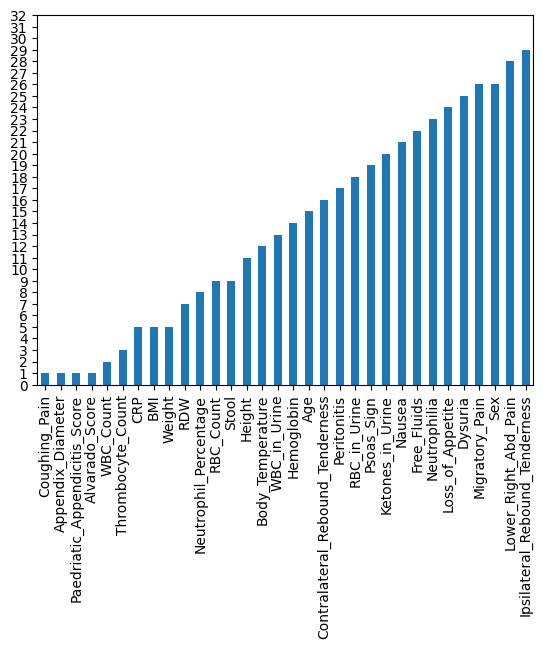

In [110]:
sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly

In [111]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [112]:
brt15 = sel_col[sel_col.values<16]
brt15.index

Index(['Coughing_Pain', 'Appendix_Diameter', 'Paedriatic_Appendicitis_Score',
       'Alvarado_Score', 'WBC_Count', 'Thrombocyte_Count', 'CRP', 'BMI',
       'Weight', 'RDW', 'Neutrophil_Percentage', 'RBC_Count', 'Stool',
       'Height', 'Body_Temperature', 'WBC_in_Urine', 'Hemoglobin', 'Age'],
      dtype='object')

In [113]:
# ruk jaana yaha....

## Shap Value

In [114]:
# !pip install shap

In [115]:
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)


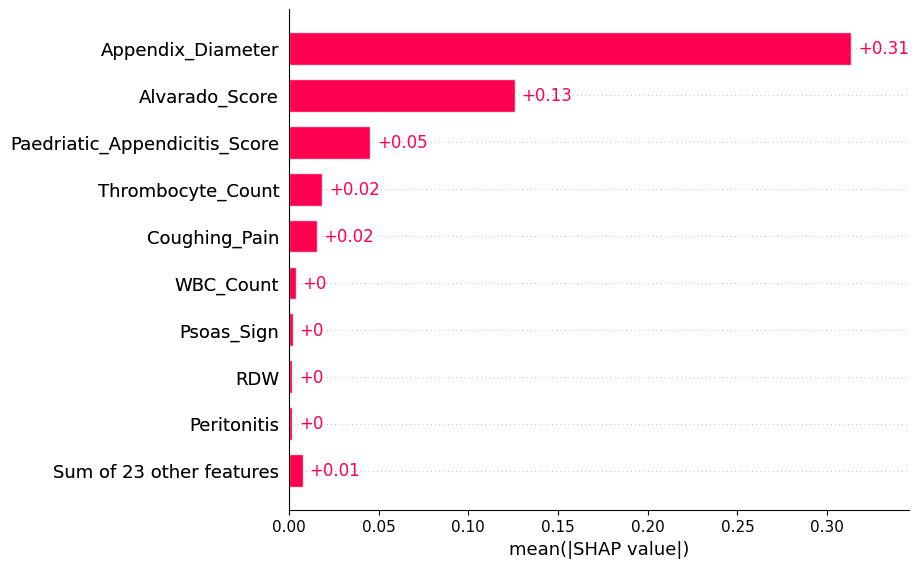

In [116]:
shap.plots.bar(shap_values)

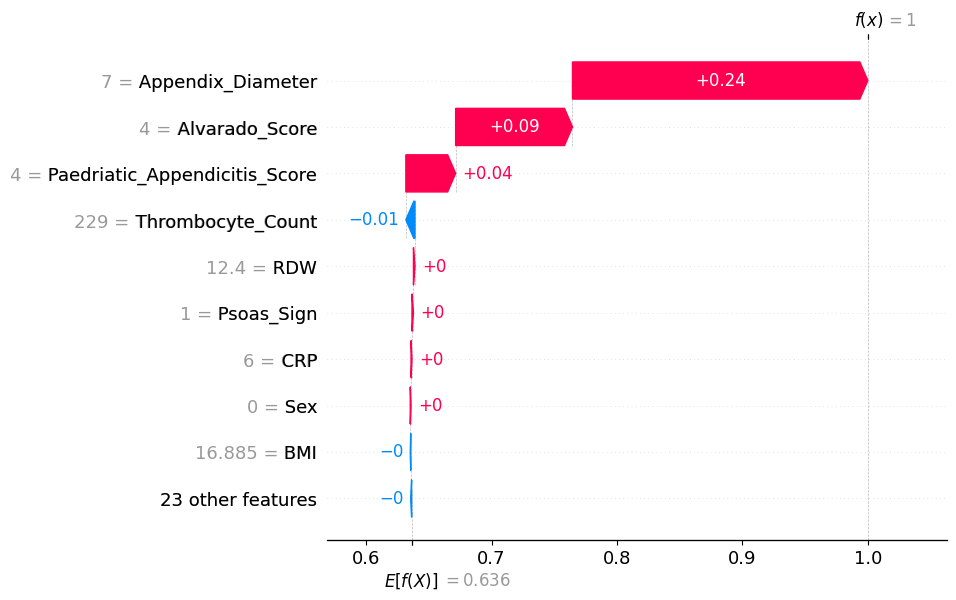

In [117]:
shap.plots.waterfall(shap_values[0])

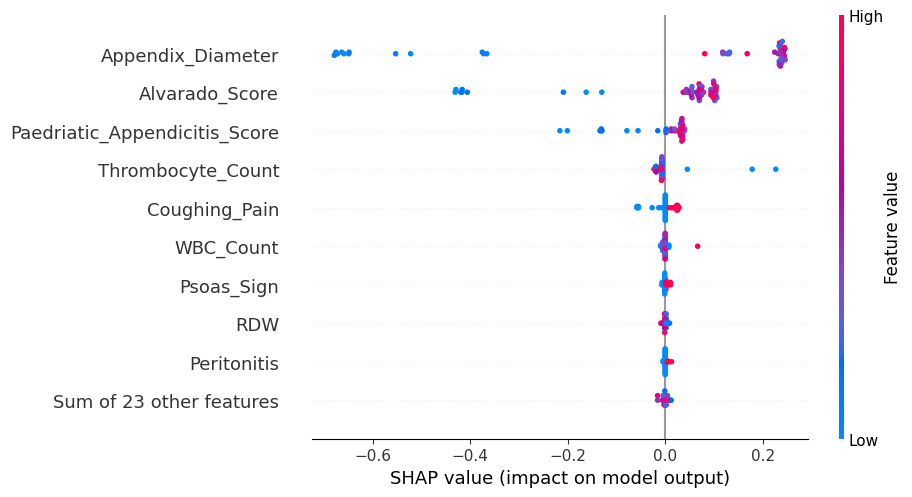

In [118]:
shap.plots.beeswarm(shap_values)

In [119]:
cols =["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score","Thrombocyte_Count","Coughing_Pain","CRP",
       "WBC_Count","Height","Peritonitis_binary"] 
cols

['Appendix_Diameter',
 'Alvarado_Score',
 'Paedriatic_Appendicitis_Score',
 'Thrombocyte_Count',
 'Coughing_Pain',
 'CRP',
 'WBC_Count',
 'Height',
 'Peritonitis_binary']

In [120]:
# error

## Information Gain

<AxesSubplot: >

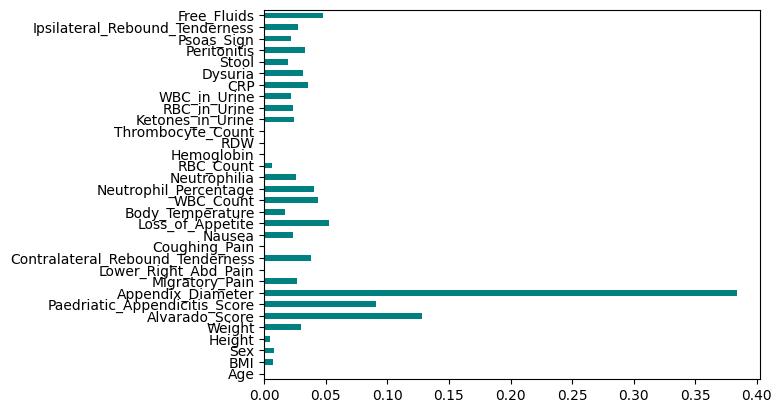

In [121]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')

In [122]:
mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

Appendix_Diameter                   0.383745
Alvarado_Score                      0.128221
Paedriatic_Appendicitis_Score       0.090304
Loss_of_Appetite                    0.052542
Free_Fluids                         0.047591
WBC_Count                           0.043349
Neutrophil_Percentage               0.040200
Contralateral_Rebound_Tenderness    0.038175
CRP                                 0.035276
Peritonitis                         0.032821
Dysuria                             0.031008
Weight                              0.029803
Ipsilateral_Rebound_Tenderness      0.026989
Migratory_Pain                      0.026507
Neutrophilia                        0.025314
Ketones_in_Urine                    0.023689
RBC_in_Urine                        0.023668
Nausea                              0.023506
Psoas_Sign                          0.022031
WBC_in_Urine                        0.021689
Stool                               0.019484
Body_Temperature                    0.016902
Sex       

In [123]:
# from sklearn.feature_selection import SelectKBest
# sel_five_cols = SelectKBest(mutual_info_classif, k=0.9)
# sel_five_cols.fit(x_train, y_train)
# x_train.columns[sel_five_cols.get_support()]

In [124]:
cols = mutual_info[mutual_info>0].index
cols
# x = x.loc[:,cols]
# x.shape

Index(['BMI', 'Sex', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Contralateral_Rebound_Tenderness', 'Nausea', 'Loss_of_Appetite',
       'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage',
       'Neutrophilia', 'RBC_Count', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign',
       'Ipsilateral_Rebound_Tenderness', 'Free_Fluids'],
      dtype='object')

In [125]:
df3 = df.loc[:,cols]
df3.dropna(inplace =True)

In [126]:
df3.shape

(241, 26)

# Applying Fisher Score for feature selection

In [127]:
# pip install skfeature-chappers

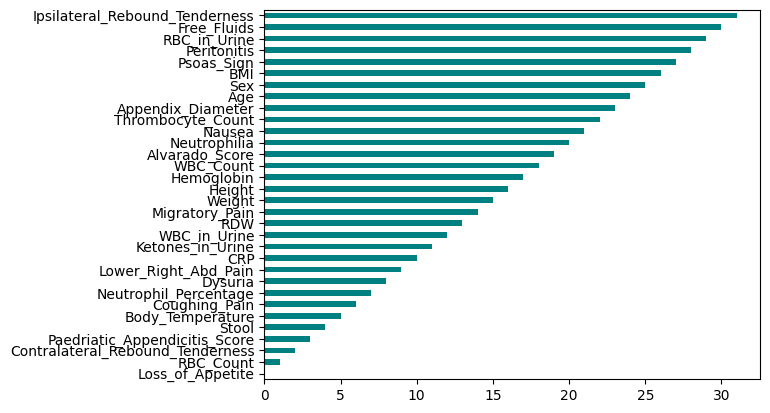

In [128]:
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(x),np.array(y))
feat_importance = pd.Series(ranks, x.columns[0:len(x.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
cols = ranks[ranks<25]

In [129]:
cols

array([24, 16, 15, 19,  3, 23, 14,  9,  2,  6, 21,  0,  5, 18,  7, 20,  1,
       17, 13, 22, 11, 12, 10,  8,  4])

In [130]:
x_= x.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_.columns)
df3.shape

The features retained after using this techniques are :
Index(['WBC_in_Urine', 'Neutrophil_Percentage', 'WBC_Count', 'Hemoglobin',
       'Height', 'RBC_in_Urine', 'Body_Temperature', 'Lower_Right_Abd_Pain',
       'Sex', 'Paedriatic_Appendicitis_Score', 'Thrombocyte_Count', 'Age',
       'Alvarado_Score', 'RBC_Count', 'Appendix_Diameter', 'RDW', 'BMI',
       'Neutrophilia', 'Loss_of_Appetite', 'Ketones_in_Urine', 'Coughing_Pain',
       'Nausea', 'Contralateral_Rebound_Tenderness', 'Migratory_Pain',
       'Weight'],
      dtype='object')


(241, 26)

## Variance Threshold as Feature Selection

In [131]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2)
x2 = v_threshold.fit_transform(x)
x2.shape

(238, 28)

In [132]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count', 'Hemoglobin',
       'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'CRP', 'Stool', 'Psoas_Sign', 'Free_Fluids'],
      dtype='object')

In [133]:
v_threshold = VarianceThreshold(threshold=0.4)
x2 = v_threshold.fit_transform(x)
x2.shape

(238, 17)

In [134]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

Index(['Age', 'BMI', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter',
       'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine',
       'RBC_in_Urine', 'CRP'],
      dtype='object')

## Chi-square Test

In [135]:
x.columns
non_cat = ["Age","BMI","Height","Weight","Appendix_Diameter","RBC_Count","Body_Temperature"]
x1 = x.drop(non_cat,axis=1)

In [136]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
#Convert to catregorial data by converting data to integers
X_cat = x1.astype(int)

#three features with highest chi-squared statistics are selected
chi2_features = SelectKBest(chi2, k =15)
X_best_features = chi2_features.fit_transform(X_cat,y)

#Reduced features
print('Original feature number :',X_cat.shape[1])
print('Reduced feature number :',X_best_features.shape[1])

Original feature number : 25
Reduced feature number : 15


In [137]:
X_best_features
selected_features = x1.columns[:][chi2_features.get_support()] 
print("\nSelected Features:") 
print(selected_features)


Selected Features:
Index(['Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Migratory_Pain',
       'Nausea', 'WBC_Count', 'Neutrophil_Percentage', 'Neutrophilia', 'RDW',
       'Thrombocyte_Count', 'Ketones_in_Urine', 'WBC_in_Urine', 'CRP',
       'Dysuria', 'Peritonitis', 'Psoas_Sign'],
      dtype='object')


In [138]:
non_cat(Index)

NameError: name 'Index' is not defined

In [ ]:
cols = df2.columns
num_cols = df._get_numeric_data().columns
print(num_cols)
# Out[68]: Index([u'0', u'1', u'2'], dtype='object')
list(set(cols) - set(num_cols))